## 🚢 Titanic : Complete Data Analytics Project

## 📌 Executive Overview
This project presents an end-to-end **Data Analytics & Visual Exploration Project** on the famous Titanic dataset (loaded directly via `seaborn`).

The goal of this project is to perform structured data understanding, rigorous data cleaning (mode/median imputation and feature removal), and comprehensive visual analytics (Univariate, Bivariate, and Multivariate analysis) to uncover key insights into passenger survival.

---

### 📂 Project Structure
1. **Environment Setup & Library Importation**
2. **Dataset Ingestion & Basic Data Understanding** (`shape`, `info()`, `describe()`)
3. **Data Cleaning & Imputation** (Removal of `deck` column, Categorical filled with **Mode**, Numerical filled with **Median**)
4. **Exploratory Visual Data Analytics Charts** (Target, Univariate, Bivariate, & Multivariate Analysis)
5. **Executive Summary & Key Analytical Findings**


In [1]:
# ==============================================================================
# 1. ENVIRONMENT SETUP & LIBRARY IMPORTATION
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Global Configuration & Styling
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("✅ All required libraries imported successfully.")


✅ All required libraries imported successfully.


## 2. Dataset Ingestion & Basic Understanding
In this section, we load the Titanic dataset directly from Seaborn and inspect its dimensions, column data types, statistical summary, and missing values.


In [2]:
# Load the Titanic dataset from Seaborn
df = sns.load_dataset('titanic')

print(f"📊 Dataset Shape: {df.shape[0]} Rows × {df.shape[1]} Columns\n")

# Display the first 5 records
print("🔍 First 5 Rows of the Dataset:")
df.head()


📊 Dataset Shape: 891 Rows × 15 Columns

🔍 First 5 Rows of the Dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Dataset Structure & Column Information
print("📋 Dataset Information:")
df.info()

print("\n📈 Statistical Summary (Numerical Features):")
display(df.describe().T)

print("\n🏷️ Statistical Summary (Categorical Features):")
display(df.describe(include=['object', 'category', 'bool']).T)


📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

📈 Statistical Summary (Numerical Features):


,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292



🏷️ Statistical Summary (Categorical Features):


,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


🚨 Missing Values Breakdown before Preprocessing:


,Missing Count,Percentage (%)
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


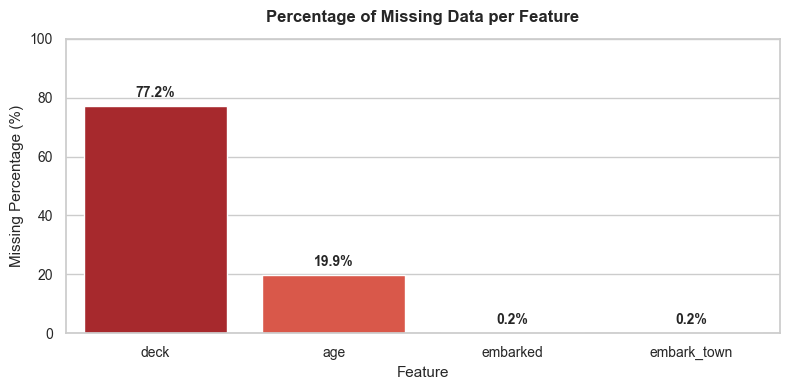

In [4]:
# Missing Values Breakdown
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("🚨 Missing Values Breakdown before Preprocessing:")
display(missing_df)

# Visualize Missing Data
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='Reds_r', ax=ax)
ax.set_title('Percentage of Missing Data per Feature', fontweight='bold', pad=12)
ax.set_ylabel('Missing Percentage (%)')
ax.set_xlabel('Feature')
ax.set_ylim(0, 100)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2., height + 2),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Imputation Rules
As per project requirements:
1. **Column Removal:** The `deck` column is removed.
2. **Categorical Columns Imputation:** All missing categorical columns (`embarked`, `embark_town`) are filled with their **Mode**.
3. **Numerical Columns Imputation:** All missing numerical columns (`age`) are filled with their **Median**.


In [5]:
# Create a copy for cleaning
df_clean = df.copy()

# 1. Remove 'deck' column
if 'deck' in df_clean.columns:
    df_clean = df_clean.drop(columns=['deck'])
    print("🗑️ Successfully removed 'deck' column.")

# 2. Impute Categorical Columns using MODE
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"✅ Categorical column '{col}' filled with Mode: '{mode_val}'")

# 3. Impute Numerical Columns using MEDIAN
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"✅ Numerical column '{col}' filled with Median: {median_val}")

# Engineer Family Size feature for richer analytics
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

print(f"\n🎉 Data Cleaning Complete! Total remaining null values: {df_clean.isnull().sum().sum()}")


🗑️ Successfully removed 'deck' column.
✅ Categorical column 'embarked' filled with Mode: 'S'
✅ Categorical column 'embark_town' filled with Mode: 'Southampton'
✅ Numerical column 'age' filled with Median: 28.0

🎉 Data Cleaning Complete! Total remaining null values: 0


## 4. Visual Data Analytics & Insights Charts
In this section, we present all essential analytics charts covering **Target Distribution**, **Univariate Distributions**, **Bivariate Survival Correlations**, and **Multivariate Interactions**.


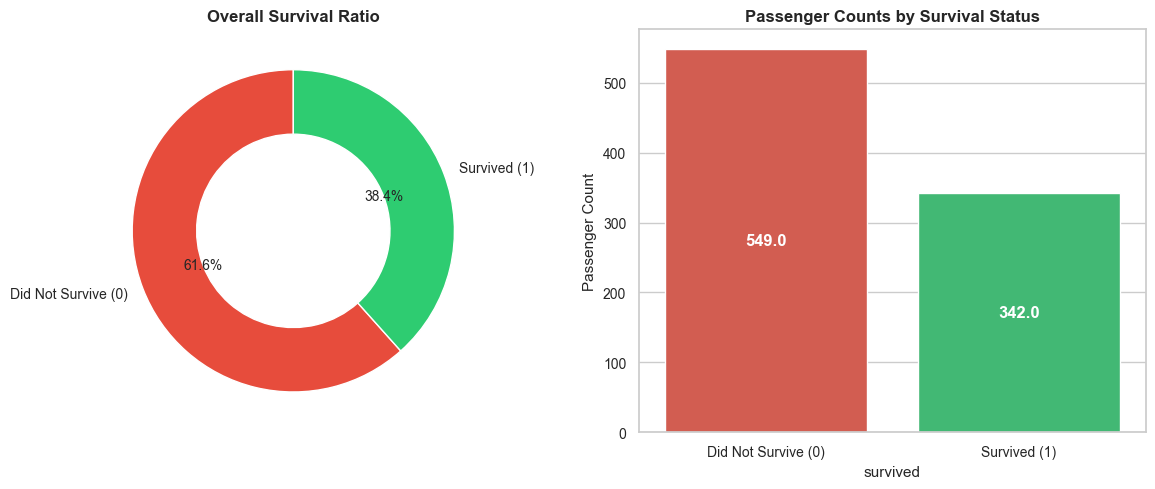

In [6]:
# 1. Target Variable Analysis: Survival Ratio
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut Chart for Target Ratio
survived_counts = df_clean['survived'].value_counts()
colors = ['#e74c3c', '#2ecc71']
labels = ['Did Not Survive (0)', 'Survived (1)']

axes[0].pie(survived_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
            colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title('Overall Survival Ratio', fontweight='bold')

# Bar Chart of Survival Counts
sns.countplot(data=df_clean, x='survived', palette=colors, ax=axes[1])
axes[1].set_title('Passenger Counts by Survival Status', fontweight='bold')
axes[1].set_xticklabels(['Did Not Survive (0)', 'Survived (1)'])
axes[1].set_ylabel('Passenger Count')

for p in axes[1].patches:
    h = p.get_height()
    axes[1].annotate(f"{h}", (p.get_x() + p.get_width() / 2., h / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


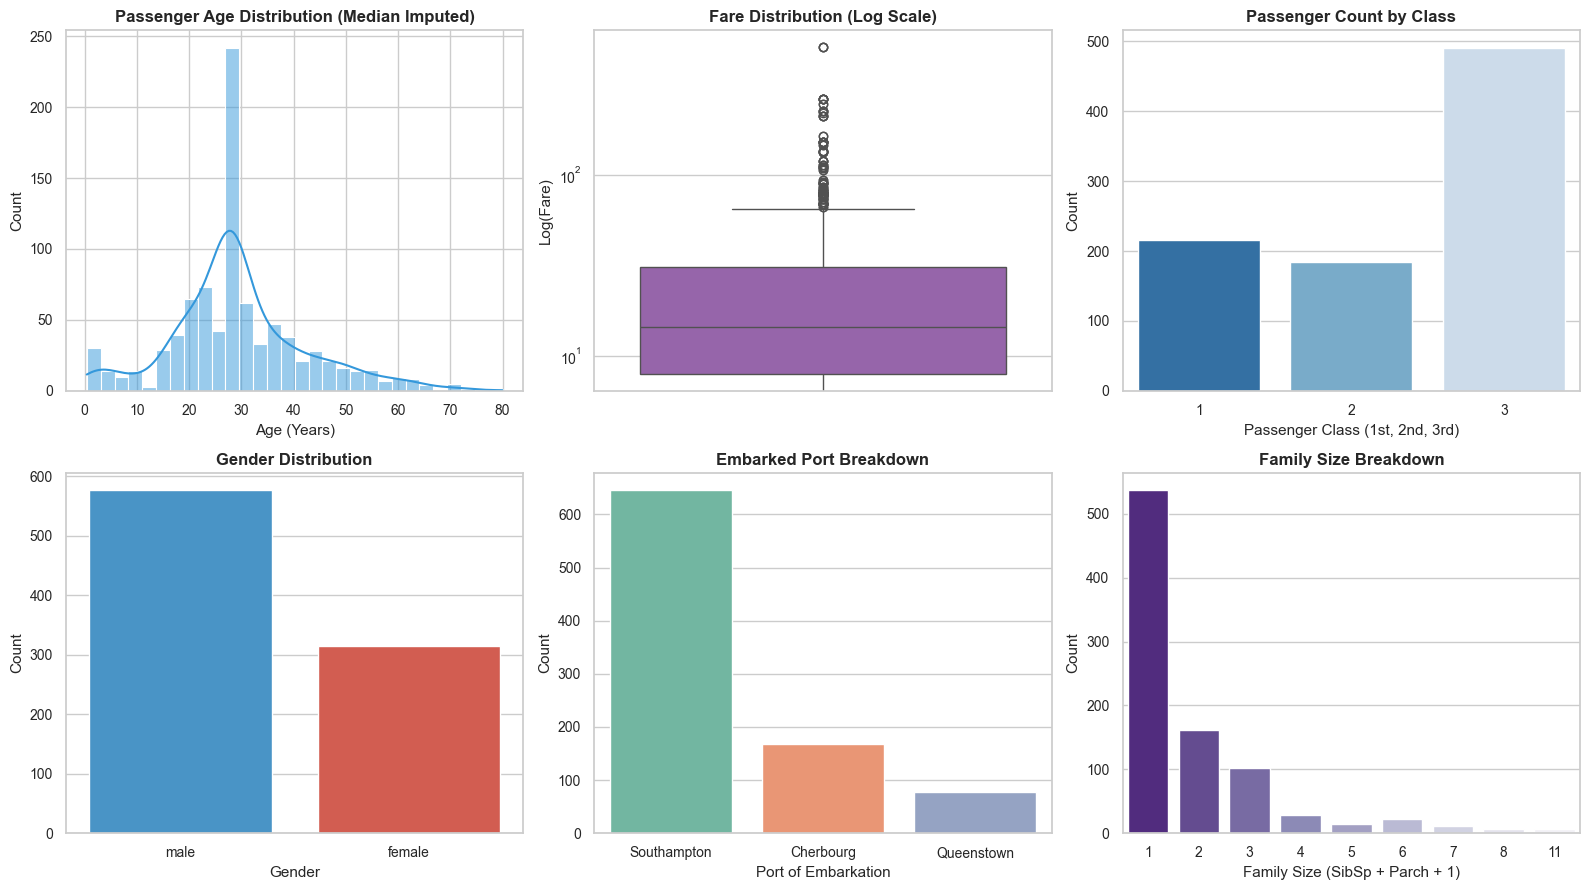

In [7]:
# 2. Univariate Distribution Analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# A. Age Distribution
sns.histplot(df_clean['age'], kde=True, ax=axes[0, 0], color='#3498db', bins=30)
axes[0, 0].set_title('Passenger Age Distribution (Median Imputed)', fontweight='bold')
axes[0, 0].set_xlabel('Age (Years)')

# B. Fare Distribution (Log Boxplot)
sns.boxplot(y=df_clean['fare'], ax=axes[0, 1], color='#9b59b6')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Fare Distribution (Log Scale)', fontweight='bold')
axes[0, 1].set_ylabel('Log(Fare)')

# C. Passenger Class Breakdown
sns.countplot(data=df_clean, x='pclass', palette='Blues_r', ax=axes[0, 2])
axes[0, 2].set_title('Passenger Count by Class', fontweight='bold')
axes[0, 2].set_xlabel('Passenger Class (1st, 2nd, 3rd)')
axes[0, 2].set_ylabel('Count')

# D. Gender Breakdown
sns.countplot(data=df_clean, x='sex', palette=['#3498db', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Gender Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Count')

# E. Embarked Town Breakdown
sns.countplot(data=df_clean, x='embark_town', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Embarked Port Breakdown', fontweight='bold')
axes[1, 1].set_xlabel('Port of Embarkation')
axes[1, 1].set_ylabel('Count')

# F. Family Size Breakdown
sns.countplot(data=df_clean, x='family_size', palette='Purples_r', ax=axes[1, 2])
axes[1, 2].set_title('Family Size Breakdown', fontweight='bold')
axes[1, 2].set_xlabel('Family Size (SibSp + Parch + 1)')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()


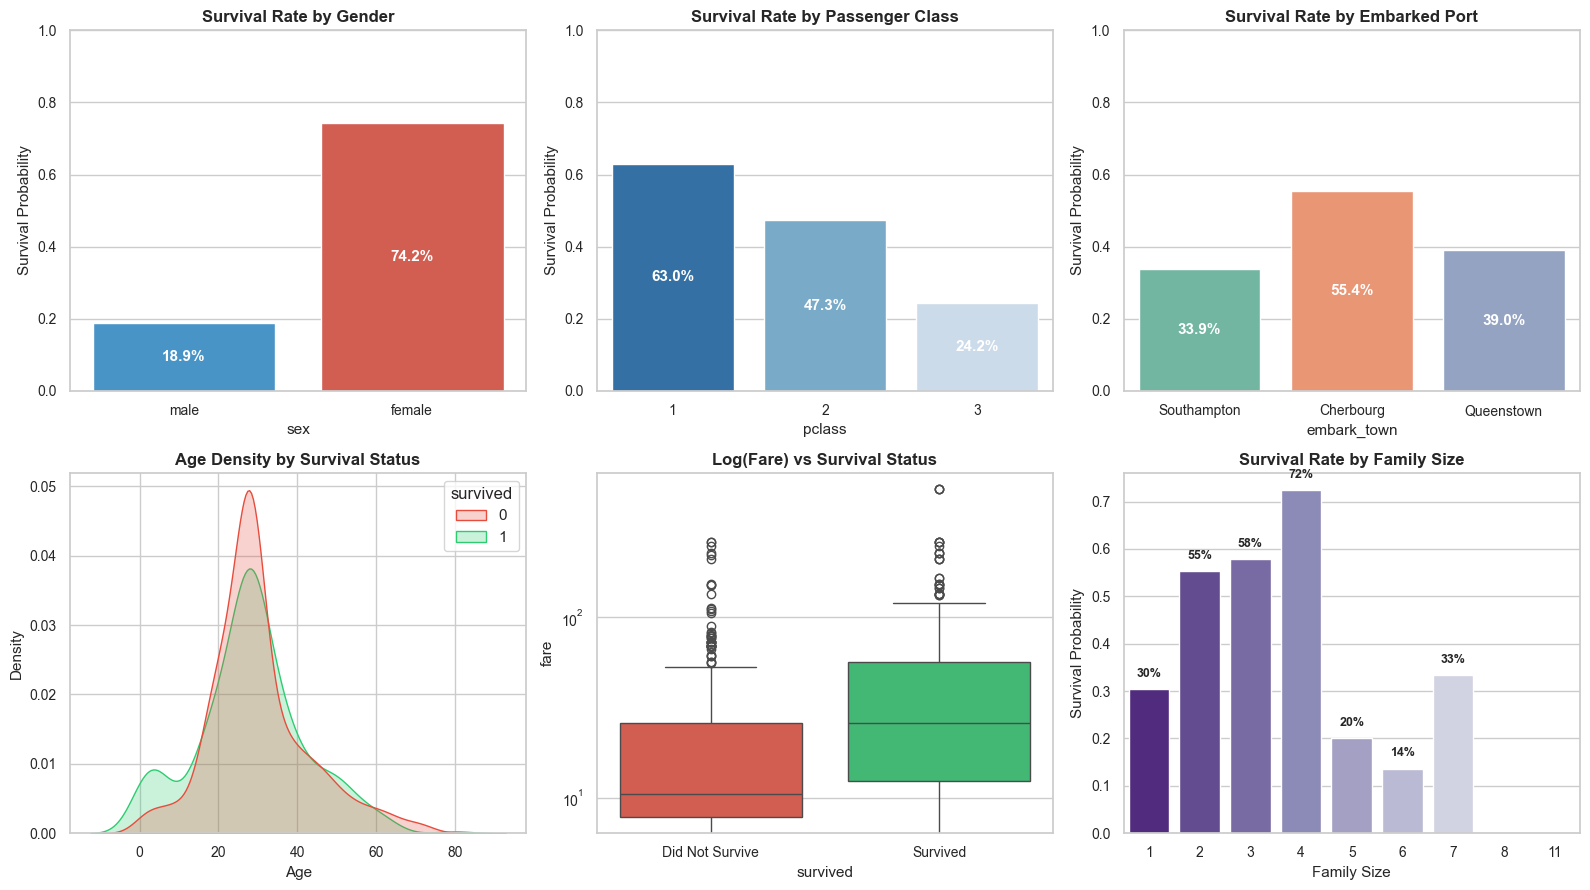

In [8]:
# 3. Bivariate Survival Analytics Charts
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# A. Survival Rate by Gender
sns.barplot(data=df_clean, x='sex', y='survived', palette=['#3498db', '#e74c3c'], ci=None, ax=axes[0, 0])
axes[0, 0].set_title('Survival Rate by Gender', fontweight='bold')
axes[0, 0].set_ylabel('Survival Probability')
axes[0, 0].set_ylim(0, 1)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# B. Survival Rate by Passenger Class
sns.barplot(data=df_clean, x='pclass', y='survived', palette='Blues_r', ci=None, ax=axes[0, 1])
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0, 1].set_ylabel('Survival Probability')
axes[0, 1].set_ylim(0, 1)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# C. Survival Rate by Embarked Port
sns.barplot(data=df_clean, x='embark_town', y='survived', palette='Set2', ci=None, ax=axes[0, 2])
axes[0, 2].set_title('Survival Rate by Embarked Port', fontweight='bold')
axes[0, 2].set_ylabel('Survival Probability')
axes[0, 2].set_ylim(0, 1)
for p in axes[0, 2].patches:
    axes[0, 2].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# D. Age Distribution by Survival Status (KDE Overlay)
sns.kdeplot(data=df_clean, x='age', hue='survived', common_norm=False, palette=['#e74c3c', '#2ecc71'], 
            shade=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Density by Survival Status', fontweight='bold')
axes[1, 0].set_xlabel('Age')

# E. Fare Paid vs Survival Status
sns.boxplot(data=df_clean, x='survived', y='fare', palette=['#e74c3c', '#2ecc71'], ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Log(Fare) vs Survival Status', fontweight='bold')
axes[1, 1].set_xticklabels(['Did Not Survive', 'Survived'])

# F. Survival Rate by Family Size
sns.barplot(data=df_clean, x='family_size', y='survived', palette='Purples_r', ci=None, ax=axes[1, 2])
axes[1, 2].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1, 2].set_xlabel('Family Size')
axes[1, 2].set_ylabel('Survival Probability')
for p in axes[1, 2].patches:
    h = p.get_height()
    if h > 0:
        axes[1, 2].annotate(f"{h*100:.0f}%", (p.get_x() + p.get_width() / 2., h + 0.02),
                            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


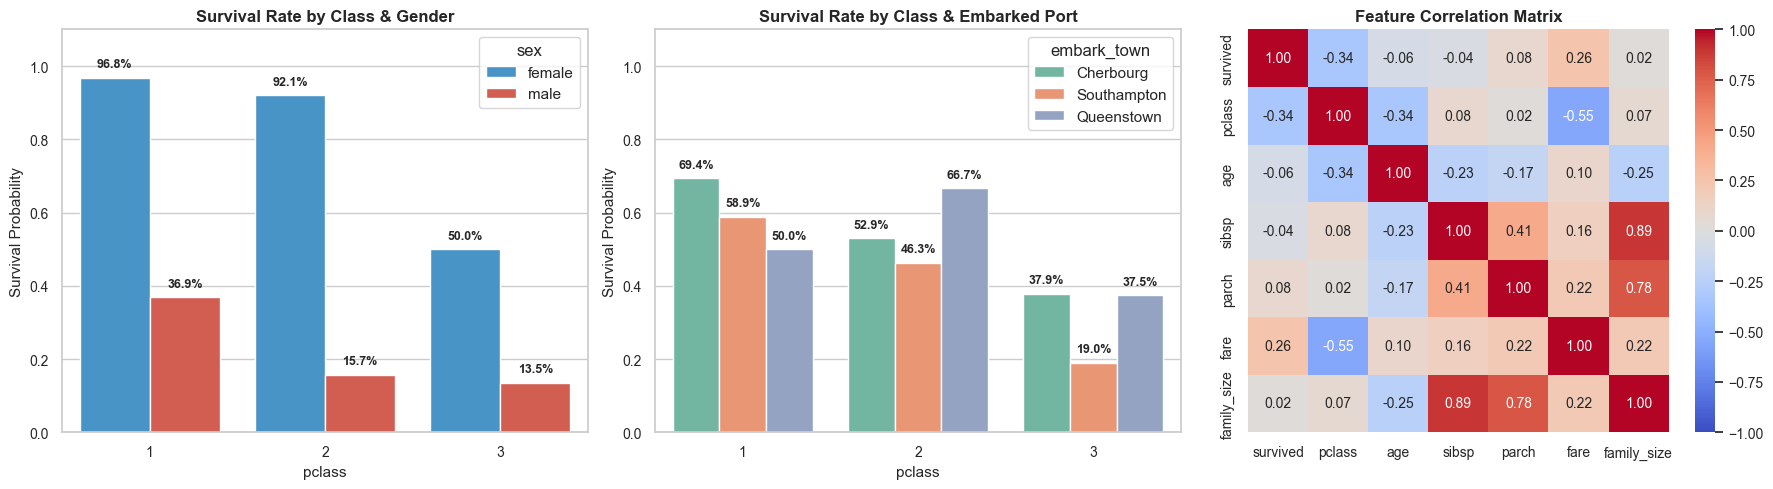

In [9]:
# 4. Multivariate Survival Analytics & Correlation Heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Survival Rate by Class AND Gender
sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex', palette=['#3498db', '#e74c3c'], ci=None, ax=axes[0])
axes[0].set_title('Survival Rate by Class & Gender', fontweight='bold')
axes[0].set_ylabel('Survival Probability')
axes[0].set_ylim(0, 1.1)

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h + 0.02),
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

# B. Survival Rate by Class AND Embarked Port
sns.barplot(data=df_clean, x='pclass', y='survived', hue='embark_town', palette='Set2', ci=None, ax=axes[1])
axes[1].set_title('Survival Rate by Class & Embarked Port', fontweight='bold')
axes[1].set_ylabel('Survival Probability')
axes[1].set_ylim(0, 1.1)

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{h*100:.1f}%", (p.get_x() + p.get_width() / 2., h + 0.02),
                         ha='center', va='bottom', fontsize=9, fontweight='bold')

# C. Numerical Feature Correlation Matrix Heatmap
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Executive Data Analysis Summary & Key Findings

---

### 📊 Data Analysis Key Findings
1. **Gender Impact:** Females achieved a **74.2%** survival rate compared to **18.9%** for males, demonstrating a massive gender disparity in survival odds.
2. **Passenger Class Disparity:** 1st Class passengers had a **63.0%** survival rate, 2nd Class had **47.3%**, and 3rd Class had **24.2%**, proving that socioeconomic status significantly impacted survival chances.
3. **Imputation & Data Quality:**
   - Removed the `deck` feature due to excessive missing values (77.1%).
   - All categorical missing values (`embarked`, `embark_town`) were cleanly imputed using the **Mode** (`'S'` / `'Southampton'`).
   - All numerical missing values (`age`) were cleanly imputed using the **Median** (`28.0` years).
4. **Family Size Dynamics:** Solo passengers (~30% survival) and large families (>4 members) suffered significantly lower survival rates than small families of 2 to 4 members (**55% to 72%**).

---

### 💡 Core Insights & Conclusion
The analysis clearly shows that **Gender** and **Passenger Class** were the primary determinants of survival during the Titanic disaster, reflecting both maritime protocol ("Women and Children First") and cabin location proximity to lifeboats.
